
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las columnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

![see](https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png?raw=true)

## Laboratorio 1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



In [3]:
# Pregunta 1
df_torgersen = df[df["isla"] == "Torgersen"]
max_beak_depth = df_torgersen["profundidad_pico (mm)"].max()
min_beak_depth = df_torgersen["profundidad_pico (mm)"].min()

print(f"Mayor profunidad de los picos de los pingüinos de la isla de Torgersen: {max_beak_depth} mm")
print(f"Menor profunidad de los picos de los pingüinos de la isla de Torgersen: {min_beak_depth} mm")

Mayor profunidad de los picos de los pingüinos de la isla de Torgersen: 21.5 mm
Menor profunidad de los picos de los pingüinos de la isla de Torgersen: 15.9 mm


In [9]:
# Pregunta 2
massive_penguin_index = df["masa_corporal (g)"].argmax()
massive_penguin = df.iloc[massive_penguin_index]

print(f"El pingüino con mayor masa corporal es un pingüino {massive_penguin.genero}, perteneciente a la especie {massive_penguin.especie} y reside en la isla {massive_penguin.isla}")

El pingüino con mayor masa corporal es un pingüino Male, perteneciente a la especie Gentoo y reside en la isla Biscoe


In [22]:
# Pregunta 3

penguins_that_match = df[np.logical_and(df.especie != "Gentoo", df.genero == "Male")]
mean_corporal_mass = penguins_that_match["masa_corporal (g)"].mean()

print(f"La masa corporal media de los pingüinos macho que no son de la especie Gentoo es de {mean_corporal_mass:.1f} gramos")

La masa corporal media de los pingüinos macho que no son de la especie Gentoo es de 4010.3 gramos


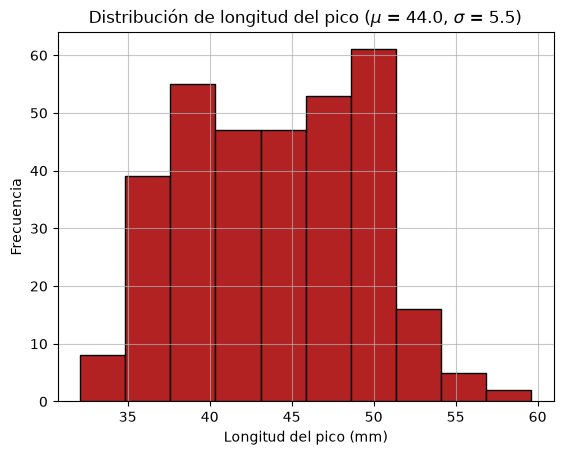

In [41]:
# Pregunta 4
import matplotlib.pyplot as plt

beak_length = df["longitud_pico (mm)"]
beak_mean = beak_length.mean()
beak_std = beak_length.std()

plt.hist(beak_length, color="firebrick",edgecolor="black")
plt.title(f"Distribución de longitud del pico ($\\mu$ = {beak_mean:.1f}, $\\sigma$ = {beak_std:.1f})")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.7)
plt.show()

La especie Adelie aparece 146 veces en el conjunto de datos
La especie Gentoo aparece 119 veces en el conjunto de datos
La especie Chinstrap aparece 68 veces en el conjunto de datos
La isla Chinstrap aparece 163 veces en el conjunto de datos
La isla Chinstrap aparece 123 veces en el conjunto de datos
La isla Chinstrap aparece 47 veces en el conjunto de datos


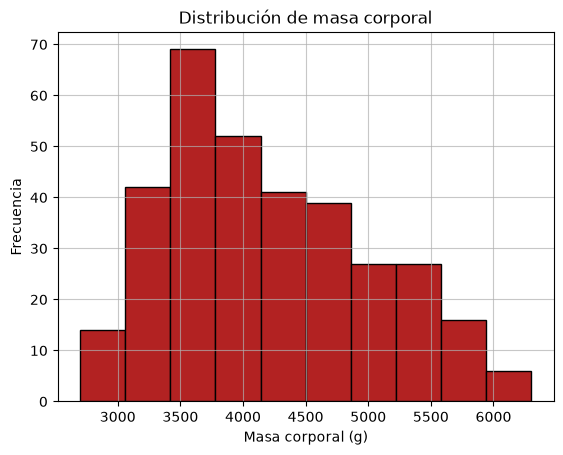

In [50]:
# Pregunta 5
species = df.especie.value_counts()
isles = df.isla.value_counts()

for specie, count in species.items():
    print(f"La especie {specie} aparece {count} veces en el conjunto de datos")

for isle, count in isles.items():
    print(f"La isla {specie} aparece {count} veces en el conjunto de datos")

corporal_mass = df["masa_corporal (g)"]

plt.hist(corporal_mass, color="firebrick",edgecolor="black")
plt.title(f"Distribución de masa corporal")
plt.xlabel("Masa corporal (g)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.7)
plt.show()
    

MUY BIEN. NOTA 5.0